# Recipe Recommendation System - food.com

**Course:** Recommendation Tools - IESEG School of Management  
**Instructor:** Fernando DIAZGONZALEZ  
**Students name:** Duc Manh NGUYEN 

---
## 1. Data Loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [45]:
train_raw = pd.read_csv('../data/train.csv')
print('Shape:', train_raw.shape)
print('Columns:', list(train_raw.columns))
print()
print('Dtypes:')
print(train_raw.dtypes)
print()
train_raw.head(5)

Shape: (165226, 5)
Columns: ['user_id', 'recipe_id', 'date', 'rating', 'review']

Dtypes:
user_id      object
recipe_id    object
date         object
rating        int64
review       object
dtype: object



,user_id,recipe_id,date,rating,review
0,U9240752,R6574412,2003-02-17,5,Great with a salad. Cooked on top of stove for...
1,U3645318,R6574412,2011-12-21,6,"So simple, so delicious! Great for chilly fall..."
2,U3478318,R2970123,2002-12-01,5,This worked very well and is EASY. I used not...
3,U8472134,R6034358,2010-02-27,6,I made the Mexican topping and took it to bunk...
4,U1522674,R6034358,2011-10-01,6,"Made the cheddar bacon topping, adding a sprin..."


In [4]:
print('Null counts:')
print(train_raw.isnull().sum())
print('Duplicates:', train_raw.duplicated().sum())

Null counts:
user_id      0
recipe_id    0
date         0
rating       0
review       0
dtype: int64
Duplicates: 0


In [46]:
meta = pd.read_csv('../data/metadata.csv')
print('Shape:', meta.shape)
print('Columns:', list(meta.columns))
print()
print('Dtypes:')
print(meta.dtypes)
print()
meta.head(5)

Shape: (231637, 12)
Columns: ['name', 'id', 'minutes', 'contributor_id', 'submitted', 'tags', 'nutrition', 'n_steps', 'steps', 'description', 'ingredients', 'n_ingredients']

Dtypes:
name              object
id                object
minutes            int64
contributor_id    object
submitted         object
tags              object
nutrition         object
n_steps            int64
steps             object
description       object
ingredients       object
n_ingredients      int64
dtype: object



,name,id,minutes,contributor_id,submitted,tags,nutrition,n_steps,steps,description,ingredients,n_ingredients
0,buttermilk pie in cornmeal pastry,R5936467,100,U1964167,1999-08-06,"['weeknight', 'time-to-make', 'course', 'main-...","[459.0, 29.0, 163.0, 13.0, 21.0, 32.0, 20.0]",24,"['for pastry: sift together flour and salt', '...","post by request. an old-fashioned, southern pie.","['flour', 'salt', 'cornmeal', 'shortening', 'c...",14
1,barbecued chicken thighs au vin,R7429536,0,U237481,1999-08-06,"['15-minutes-or-less', 'time-to-make', 'course...","[273.4, 24.0, 29.0, 3.0, 33.0, 23.0, 3.0]",15,"['put chicken thighs in a freezer bag', 'in a ...",NaN,"['chicken thighs', 'vegetable oil', 'butter', ...",11
2,20 000 prize winning chili con carne,R9643197,175,U7476978,1999-08-06,"['weeknight', 'time-to-make', 'course', 'main-...","[558.1, 25.0, 55.0, 41.0, 111.0, 25.0, 12.0]",17,"['in large saucepan or dutch oven , brown half...",NaN,"['lean chuck', 'lean pork', 'onion', 'garlic c...",18
3,chocolatey raisin chip cookies,R8459344,57,U237481,1999-08-06,"['60-minutes-or-less', 'time-to-make', 'course...","[83.5, 4.0, 34.0, 1.0, 2.0, 2.0, 4.0]",14,"['preheat oven to 375f', 'combine sugars and o...",NaN,"['brown sugar', 'sugar', 'canola oil', 'vanill...",13
4,grape nuts pie,R3247719,75,U237481,1999-08-06,"['weeknight', 'time-to-make', 'course', 'main-...","[2257.0, 76.0, 982.0, 61.0, 52.0, 133.0, 150.0]",6,"['combine grapenuts and warm water', 'let stan...",NaN,"['grape-nuts cereal', 'water', 'eggs', 'sugar'...",8


In [6]:
print('Null counts:')
print(meta.isnull().sum())
print('Duplicates:', meta.duplicated().sum())

Null counts:
name                 1
id                   0
minutes              0
contributor_id       0
submitted            0
tags                 0
nutrition            0
n_steps              0
steps                0
description       4979
ingredients          0
n_ingredients        0
dtype: int64
Duplicates: 0


---
## 2. Exploratory Data Analysis

### 2.1 Rating Distribution

In [7]:
print(train_raw['rating'].value_counts().sort_index())
print(); print(train_raw['rating'].describe())

rating
1      5561
2      1460
3      2460
4      6897
5     27799
6    121049
Name: count, dtype: int64

count    165226.000000
mean          5.499970
std           1.096358
min           1.000000
25%           5.000000
50%           6.000000
75%           6.000000
max           6.000000
Name: rating, dtype: float64


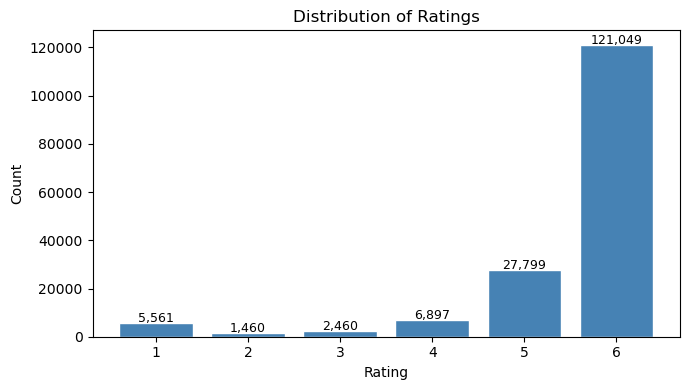

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
rc = train_raw['rating'].value_counts().sort_index()
ax.bar(rc.index, rc.values, color='steelblue', edgecolor='white')
for x, y in zip(rc.index, rc.values):
    ax.text(x, y+500, f'{y:,}', ha='center', fontsize=9)
ax.set_xlabel('Rating')
ax.set_ylabel('Count')
ax.set_title('Distribution of Ratings')
ax.set_xticks(rc.index)
plt.tight_layout()
plt.show()

**Observation:** Rating 6 accounts for ≈ 73% of interactions - an extreme positive skew. 

### 2.2 Unique Users and Recipes

In [9]:
n_users   = train_raw['user_id'].nunique()
n_recipes = train_raw['recipe_id'].nunique()
n_ratings = len(train_raw)
print(f'Unique users: {n_users:,}   Unique recipes: {n_recipes:,}   Total ratings: {n_ratings:,}')

Unique users: 11,346   Unique recipes: 62,517   Total ratings: 165,226


### 2.3 Ratings per User

In [10]:
ratings_per_user = train_raw.groupby('user_id')['rating'].count()
print(ratings_per_user.describe())
print(f'Mean: {ratings_per_user.mean():.2f}  Median: {ratings_per_user.median():.0f}')

count    11346.000000
mean        14.562489
std          2.247612
min          1.000000
25%         13.000000
50%         16.000000
75%         16.000000
max         16.000000
Name: rating, dtype: float64
Mean: 14.56  Median: 16


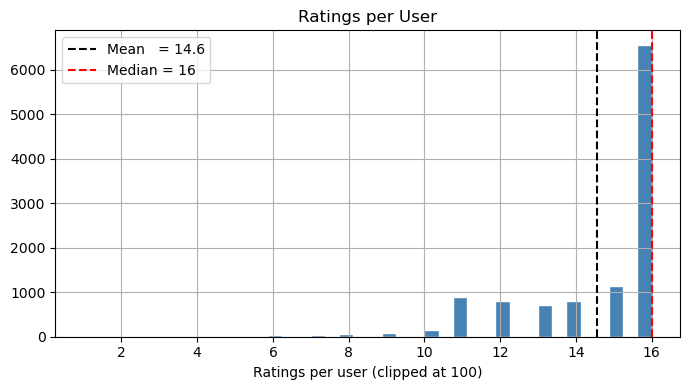

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
ratings_per_user.clip(upper=100).hist(bins=40, ax=ax, color='steelblue', edgecolor='white')
ax.axvline(ratings_per_user.mean(),   color='black', linestyle='--', label=f'Mean   = {ratings_per_user.mean():.1f}')
ax.axvline(ratings_per_user.median(), color='red',   linestyle='--', label=f'Median = {ratings_per_user.median():.0f}')
ax.set_xlabel('Ratings per user (clipped at 100)'); ax.set_title('Ratings per User'); ax.legend()
plt.tight_layout(); plt.show()

**Observation:** The distribution is left-skewed, as the mean (14.56) is lower than the median (16). Most users in this sample are highly active, frequently reaching the 16-rating mark.

### 2.4 Ratings per Recipe

In [12]:
ratings_per_recipe = train_raw.groupby('recipe_id')['rating'].count()
print(ratings_per_recipe.describe())
print(f'Mean: {ratings_per_recipe.mean():.2f}  Median: {ratings_per_recipe.median():.0f}')

count    62517.000000
mean         2.642897
std          7.155073
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max        364.000000
Name: rating, dtype: float64
Mean: 2.64  Median: 1


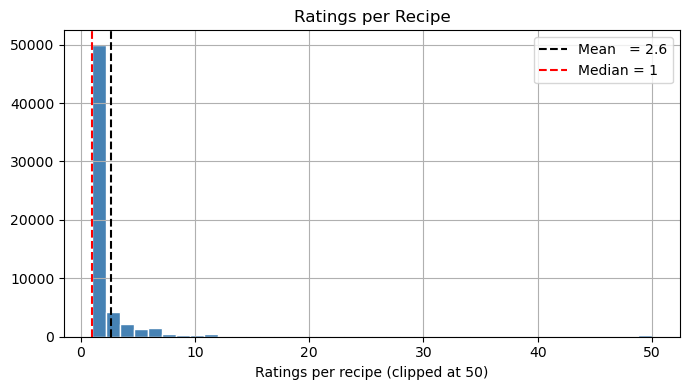

In [13]:
fig, ax = plt.subplots(figsize=(7, 4))
ratings_per_recipe.clip(upper=50).hist(bins=40, ax=ax, color='steelblue', edgecolor='white')
ax.axvline(ratings_per_recipe.mean(),   color='black', linestyle='--', label=f'Mean   = {ratings_per_recipe.mean():.1f}')
ax.axvline(ratings_per_recipe.median(), color='red',   linestyle='--', label=f'Median = {ratings_per_recipe.median():.0f}')
ax.set_xlabel('Ratings per recipe (clipped at 50)'); ax.set_title('Ratings per Recipe'); ax.legend()
plt.tight_layout(); plt.show()

**Observation:** Extreme long tail - most recipes have only 1-2 ratings. CF will struggle with niche recipes.

### 2.5 Matrix Sparsity

In [14]:
density  = n_ratings / (n_users * n_recipes)
sparsity = 1 - density
print(f'Matrix: {n_users:,} × {n_recipes:,} = {n_users*n_recipes:,} cells')
print(f'Density: {density*100:.4f}%   Sparsity: {sparsity*100:.4f}%')

Matrix: 11,346 × 62,517 = 709,317,882 cells
Density: 0.0233%   Sparsity: 99.9767%


**Observation:** 99.97% of the matrix is empty, it means that the average recipe has very few ratings. In this case, SVD would perform better than User-Based CF in the final results.

---
## 3. Train / Validation / Test Split

Random 70 / 15 / 15 split with `random_state=42`. Validation is used for hyperparameter tuning; test is held out for final comparison.

In [15]:
from sklearn.model_selection import train_test_split

interactions = train_raw[['user_id', 'recipe_id', 'rating']].copy()
train_val, test = train_test_split(interactions, test_size=0.15, random_state=42)
train, val      = train_test_split(train_val, test_size=0.15/0.85, random_state=42)
train = train.reset_index(drop=True)
val   = val.reset_index(drop=True)
test  = test.reset_index(drop=True)

print(f'Train: {len(train):,} ({len(train)/len(interactions)*100:.1f}%)')
print(f'Val:   {len(val):,} ({len(val)/len(interactions)*100:.1f}%)')
print(f'Test:  {len(test):,} ({len(test)/len(interactions)*100:.1f}%)')

Train: 115,658 (70.0%)
Val:   24,784 (15.0%)
Test:  24,784 (15.0%)


In [16]:
train_users   = set(train['user_id'])
train_recipes = set(train['recipe_id'])
print('Cold-start users  (val / test):', len(set(val['user_id'])-train_users), '/', len(set(test['user_id'])-train_users))
print('Cold-start recipes(val / test):', len(set(val['recipe_id'])-train_recipes), '/', len(set(test['recipe_id'])-train_recipes))

Cold-start users  (val / test): 2 / 5
Cold-start recipes(val / test): 6751 / 6757


**Observation:** 
* **User Cold-Start:** Since there are 2 and 5 new users for each set,
     the cold-start problem for users is negligible. The model
     would be able to personalize for almost every user in the
     evaluation sets.
* **Recipe Cold-Start:** On the other hand, over 6,700
     recipes in both validation and test sets have zero ratings in
     the training data. This represents approximately 27% of our
     total evaluation interactions.
* **Impact:** For these thousands of cold-start recipes,
     Collaborative Filtering (KNN) may be unable to find similar
     items or neighbors and will be forced to fall back to the
     global mean prediction. 

---
## 4. Content-Based Recommender

We build TF-IDF features from recipe tags, ingredients and description, then use cosine similarity between recipe vectors to generate predictions (item-based weighted-sum formula from the slides). Evaluated on the validation set.

In [17]:
import ast
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize

def parse_list_col(cell):
    try:
        items = ast.literal_eval(str(cell))
        return ' '.join(str(x) for x in items)
    except (ValueError, SyntaxError):
        return str(cell)

all_recipe_ids = set(train_raw['recipe_id'])
meta_cb = meta[meta['id'].isin(all_recipe_ids)].copy().reset_index(drop=True)
print(f'Recipes in interactions: {len(all_recipe_ids):,}  |  Found in metadata: {len(meta_cb):,} (100%)')

meta_cb['document'] = (meta_cb['tags'].fillna('').apply(parse_list_col) + ' ' +
                       meta_cb['ingredients'].fillna('').apply(parse_list_col) + ' ' +
                       meta_cb['description'].fillna(''))

print(f"\nSample ('{meta_cb.iloc[0]['name']}'): {meta_cb.iloc[0]['document'][:120]}")

Recipes in interactions: 62,517  |  Found in metadata: 62,517 (100%)

Sample ('barbecued chicken thighs au vin'): 15-minutes-or-less time-to-make course main-ingredient preparation main-dish poultry barbecue chicken stove-top dietary 


In [18]:
# TF-IDF: stop_words='english', max_features=5000, sublinear_tf dampens frequent-term dominance
tfidf_vec  = TfidfVectorizer(stop_words='english', max_features=5000, sublinear_tf=True)
tfidf_mat  = tfidf_vec.fit_transform(meta_cb['document'])
tfidf_norm = normalize(tfidf_mat, norm='l2')  # L2-norm → dot product = cosine similarity

recipe_to_idx = dict(zip(meta_cb['id'], range(len(meta_cb))))
idx_to_recipe = dict(zip(range(len(meta_cb)), meta_cb['id']))
idx_to_name   = dict(zip(range(len(meta_cb)), meta_cb['name'].fillna('Unknown')))

print(f'TF-IDF matrix: {tfidf_mat.shape}   Non-zero: {tfidf_mat.nnz:,}')

TF-IDF matrix: (62517, 5000)   Non-zero: 3,172,984


In [19]:
RATING_MIN, RATING_MAX = 1, 6
global_mean_cb = train['rating'].mean()
print(f'Global mean rating (training): {global_mean_cb:.4f}')

def predict_cb(recipe_id, rated_mat, rated_ratings_arr, K=10):
    # weighted average of the K most similar recipes the user has already rated
    if recipe_id not in recipe_to_idx:
        return global_mean_cb
    t_idx = recipe_to_idx[recipe_id]
    t_vec = tfidf_norm[t_idx]                           # sparse (1 x n_features)
    sims  = t_vec.dot(rated_mat.T).toarray().flatten()  # cosine sims with rated recipes
    top_k_idx   = np.argsort(sims)[::-1][:min(K, len(sims))]
    top_sims    = sims[top_k_idx]
    top_ratings = rated_ratings_arr[top_k_idx]
    pos = top_sims > 0
    if pos.sum() == 0:
        return global_mean_cb
    weighted_pred = np.dot(top_sims[pos], top_ratings[pos]) / top_sims[pos].sum()
    return float(np.clip(weighted_pred, RATING_MIN, RATING_MAX))

Global mean rating (training): 5.4994


In [20]:
# Pre-build user → {recipe_id: rating} lookup from training set
user_train_lookup = {}
for _, row in train.iterrows():
    uid = row['user_id']
    if uid not in user_train_lookup:
        user_train_lookup[uid] = {}
    user_train_lookup[uid][row['recipe_id']] = row['rating']
print(f'Users in training lookup: {len(user_train_lookup):,}')

Users in training lookup: 11,339


### 4.1 Sample Recommendations

We select the user's 3 highest-rated training recipes as seeds, compute cosine similarities against all 62,517 recipes, aggregate scores, and return the top-5 unseen recommendations.

In [21]:
def get_value(pair):
    # return second element of a tuple (used to sort by rating or similarity score)
    return pair[1]

def recommend_top_n_cb(user_id, n=5, k_seeds=3, k_sim=30):
    rated = user_train_lookup.get(user_id, {})
    already_rated = set(rated.keys())

    # pick the top-rated recipes by this user as starting seeds
    sorted_rated = sorted(rated.items(), key=get_value, reverse=True)
    seeds = []
    for recipe_id, rating_val in sorted_rated[:k_seeds]:
        if recipe_id in recipe_to_idx:
            seeds.append(recipe_id)
    if not seeds:
        return []

    # accumulate similarity scores from each seed recipe
    candidate_scores = {}
    for seed_id in seeds:
        sv = tfidf_norm[recipe_to_idx[seed_id]]
        all_sims = sv.dot(tfidf_norm.T).toarray().flatten()
        for idx in np.argsort(all_sims)[::-1][:k_sim + len(already_rated) + 1]:
            r_id = idx_to_recipe[idx]
            if r_id not in already_rated:
                candidate_scores[r_id] = candidate_scores.get(r_id, 0) + all_sims[idx]

    top_n = sorted(candidate_scores.items(), key=get_value, reverse=True)[:n]

    recommendations = []
    for r_id, score in top_n:
        if r_id in recipe_to_idx:
            name = idx_to_name[recipe_to_idx[r_id]]
            recommendations.append((r_id, name, round(score, 4)))
    return recommendations

demo_users = [uid for uid, rated in user_train_lookup.items() if len(rated) >= 10][:3]
for uid in demo_users:
    rated = user_train_lookup[uid]
    top_liked = sorted(rated.items(), key=get_value, reverse=True)[:2]
    liked_names = []
    for r_id, _ in top_liked:
        idx = recipe_to_idx.get(r_id, -1)
        if idx != -1:
            liked_names.append(idx_to_name[idx])
        else:
            liked_names.append(r_id)
    print(f'\n--- User {uid} ({len(rated)} ratings) ---')
    print('  Liked:', liked_names)
    recs = recommend_top_n_cb(uid, n=5)
    print('  Top-5 recommendations:')
    for i, (r_id, name, score) in enumerate(recs, 1):
        print(f'    {i}. {name} (sim={score})')


--- User U8305103 (11 ratings) ---
  Liked: ['baked ziti', 'smothered pork chops']
  Top-5 recommendations:
    1. rigatoni and sausage bake (sim=0.6395)
    2. baked ziti with spinach  sausage  and mozzarella (sim=0.6323)
    3. zippity do dah baked ziti (sim=0.6305)
    4. grilled honey garlic pork chops (sim=0.6287)
    5. quick and easy baked ziti (sim=0.617)

--- User U9734680 (14 ratings) ---
  Liked: ['mormon split pea soup', 'indian lentil soup  dal shorva']
  Top-5 recommendations:
    1. roasted cauliflower with garlic (sim=0.4065)
    2. split pea soup (sim=0.4059)
    3. roasted potatoes with rosemary (sim=0.3976)
    4. roasted red lentil soup (sim=0.3883)
    5. broccoli cauliflower roast (sim=0.3774)

--- User U314329 (10 ratings) ---
  Liked: ['cracker barrel s hashbrowns casserole   copycat', 'spooky eyeballs']
  Top-5 recommendations:
    1. barrel of crackers hash browns casserole   copycat (sim=0.6107)
    2. tater casserole for 10 (sim=0.5636)
    3. cracker barre

**Observation:** The recommendations are semantically consistent. For example, users who liked baked pasta dishes receive similar pasta bakes; soup lovers receive similar soups. The output confirms that the model discovers recipe similarity from shared ingredient and tag vocabulary, without relying on any other users' ratings.

### 4.2 Evaluation on Validation Set

For each (user, recipe) pair in validation: predict using the content-based formula; fall back to global mean when the recipe has no metadata or the user has no training ratings.

In [22]:
preds_cb_val, acts_cb_val, n_cold_cb = [], [], 0

for uid, grp in val.groupby('user_id'):
    rated = user_train_lookup.get(uid, {})
    # collect the recipes this user rated that appear in the metadata
    in_mat = []
    for r, v in rated.items():
        if r in recipe_to_idx:
            in_mat.append((r, v))
    if not in_mat:
        preds_cb_val.extend([global_mean_cb] * len(grp))
        acts_cb_val.extend(grp['rating'].tolist())
        n_cold_cb += len(grp)
        continue
    row_indices = []
    for r, _ in in_mat:
        row_indices.append(recipe_to_idx[r])
    rated_mat_u = tfidf_norm[row_indices]
    rated_rat_u = np.array([v for _, v in in_mat])
    for rid, actual in zip(grp['recipe_id'].values, grp['rating'].values):
        pred = predict_cb(rid, rated_mat_u, rated_rat_u)
        preds_cb_val.append(pred)
        if pred == global_mean_cb:
            n_cold_cb += 1
        acts_cb_val.append(actual)

preds_cb_val = np.array(preds_cb_val)
acts_cb_val  = np.array(acts_cb_val)
print(f'Done. {len(preds_cb_val):,} predictions  |  Global-mean fallbacks: {n_cold_cb:,} ({n_cold_cb/len(preds_cb_val)*100:.1f}%)')

Done. 24,784 predictions  |  Global-mean fallbacks: 3 (0.0%)


In [23]:
# Shared evaluation helper - used for all three models
def eval_metrics(preds_arr, acts_arr, threshold=4, label=''):
    """Compute and print RMSE, MAE, Recall, Precision, F1."""
    rmse = np.sqrt(np.mean((preds_arr - acts_arr)**2))
    mae  = np.mean(np.abs(preds_arr - acts_arr))
    pb = (preds_arr >= threshold).astype(int)
    tb = (acts_arr  >= threshold).astype(int)
    TP = int(np.sum((pb==1)&(tb==1)))
    FP = int(np.sum((pb==1)&(tb==0)))
    FN = int(np.sum((pb==0)&(tb==1)))
    recall    = TP/(TP+FN) if (TP+FN)>0 else 0.0
    precision = TP/(TP+FP) if (TP+FP)>0 else 0.0
    f1 = 2*precision*recall/(precision+recall) if (precision+recall)>0 else 0.0
    print(f'{label}')
    print(f'  RMSE:      {rmse:.4f}')
    print(f'  MAE:       {mae:.4f}')
    print(f'  Recall:    {recall:.4f}')
    print(f'  Precision: {precision:.4f}')
    print(f'  F1:        {f1:.4f}')
    return {'RMSE': rmse, 'MAE': mae, 'Recall': recall, 'Precision': precision, 'F1': f1}

metrics_cb_val = eval_metrics(preds_cb_val, acts_cb_val, label='Content-Based - Validation Metrics')

Content-Based - Validation Metrics
  RMSE:      1.1118
  MAE:       0.6619
  Recall:    0.9820
  Precision: 0.9461
  F1:        0.9637


**Observation**: The content-based model shows moderate results in terms of both RMSE & MAE. Recall and Precision are high; however, these values are inflated by the skewed rating distribution (≈ 94% of actual ratings are ≥ 4). Therefore, while the model can effectively identify recipe similarities based on semantic relationships, it does not have the ability to be personalized to individual users' preferences.

---
## 5. Collaborative Filtering

Collaborative Filtering identifies people who have similar past ratings patterns and recommends items that similar users liked, without any item metadata.

We implemented **User-Based Collaborative Filtering**, using the **KNN Basic** Class From Scikit-Surprise, and using Cosine Similarity and K = 20 Neighbors to fit our model to the training data and evaluate it on the validation data.

In [24]:
from surprise import Dataset, Reader, KNNBasic, SVD, accuracy

reader   = Reader(rating_scale=(1, 6))
df_train = Dataset.load_from_df(train[['user_id','recipe_id','rating']], reader).build_full_trainset()
df_val   = list(val[['user_id','recipe_id','rating']].itertuples(index=False, name=None))
df_test  = list(test[['user_id','recipe_id','rating']].itertuples(index=False, name=None))

print(f'Training set: {df_train.n_ratings:,} ratings, {df_train.n_users} users, {df_train.n_items} items')
print(f'Rating scale: {reader.rating_scale}')

Training set: 115,658 ratings, 11339 users, 49572 items
Rating scale: (1, 6)


In [28]:
# User-based KNNBasic with cosine similarity 
options_ub = {'name': 'cosine', 'user_based': True}
ub = KNNBasic(k=20, min_k=5, sim_options=options_ub, random_state=42)

print('Fitting user-based KNNBasic...')
ub.fit(df_train)  # computes 11,339 x 11,339 cosine similarity matrix
print('Done.')

pred_ub_val = ub.test(df_val)

Fitting user-based KNNBasic...
Computing the cosine similarity matrix...
Done computing similarity matrix.
Done.


In [29]:
# How many predictions are impossible (no shared rated items with any neighbour)?
n_impossible = 0
for p in pred_ub_val:
    if p.details['was_impossible']:
        n_impossible += 1
print(f'\nValidation predictions: {len(pred_ub_val):,}')
print(f'Impossible (global-mean fallback): {n_impossible:,} ({n_impossible/len(pred_ub_val)*100:.1f}%)')


Validation predictions: 24,784
Impossible (global-mean fallback): 24,074 (97.1%)


**Observation**: It appears that there aren't enough neighbors among those users that have already rated the target recipe. This is a direct consequence of the 99.97% matrix sparsity as we discovered in the EDA step: most recipes have only 1-2 raters, so for any given (user,recipe) pair, the model can’t predict anything based on their neighboring users. The model falls back to the global mean for these cases
.

In [ ]:
preds_ub_val = np.array([p.est  for p in pred_ub_val])
acts_ub_val  = np.array([p.r_ui for p in pred_ub_val])

metrics_ub_val = eval_metrics(preds_ub_val, acts_ub_val, label='User-Based CF - Validation Metrics')

User-Based CF - Validation Metrics
  RMSE:      1.1035
  MAE:       0.7354
  Recall:    0.9999
  Precision: 0.9414
  F1:        0.9698


**Observation:** The User-Based CF delivers metrics similar to a non-personalized baseline because as we observed above, almost all predictions falling back to the global mean. That's why RMSE and MAE only reflect reflect the average distance from the global mean to actual ratings. Recall and Precision are again  inflated by the skewed rating distribution. This result is expected and is a popular limitation of neighbourhood-based CF on highly sparse datasets


---
## 6. Matrix Factorization (SVD)

SVD (Singular Value Decomposition), is a model-based approach that separates the Rating Matrix into User Factor Latent Matrix, and Item Factor Latent Matrix. Unlike Neighbourhood Based CF, SVD uses all observed ratings simultaneously to generate a dense representation of the latent factors, making it more robust to sparsity.

We use `surprise.SVD` with `biased=True` (includes user and item bias terms) 

### 6.1 Hyperparameter Tuning on Validation Set

We use a manual loop to try different combinations of n_factors and n_epochs on the validation set. For each combination, the model is fitted on the training set and scored on the validation set using RMSE and MAE.

| Parameter | Values tested | What it controls |
|---|---|---|
| `n_factors` | 5, 20, 50 | Number of latent dimensions - determines model capacity |
| `n_epochs` | 10, 20 | Number of SGD passes over the observed ratings |

For each of the 3 × 2 = 6 combinations, the model is fitted on the training set and scored on the validation set. The combination with the lowest RMSE is selected as the best model.

In [30]:
# try different SVD hyperparameter combinations and score each on the validation set
n_factors_options = [5, 20, 50]
n_epochs_options  = [10, 20]

results = []
for n_factors in n_factors_options:
    for n_epochs in n_epochs_options:
        svd_try = SVD(n_factors=n_factors, n_epochs=n_epochs, biased=True, random_state=42)
        svd_try.fit(df_train)
        preds_val = svd_try.test(df_val)
        rmse_val = accuracy.rmse(preds_val, verbose=False)
        mae_val  = accuracy.mae(preds_val,  verbose=False)
        results.append({'n_factors': n_factors, 'n_epochs': n_epochs,
                        'Val_RMSE': round(rmse_val, 4), 'Val_MAE': round(mae_val, 4)})
        print(f'n_factors={n_factors}, n_epochs={n_epochs} -> RMSE={rmse_val:.4f}')

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Val_RMSE').reset_index(drop=True)
print('\nAll combinations sorted by validation RMSE:')
print(results_df.to_string(index=False))

best_n_factors = int(results_df.iloc[0]['n_factors'])
best_n_epochs  = int(results_df.iloc[0]['n_epochs'])
print(f'\nBest params: n_factors={best_n_factors}, n_epochs={best_n_epochs}')
print(f'Best Val RMSE: {results_df.iloc[0]["Val_RMSE"]:.4f}')

n_factors=5, n_epochs=10 -> RMSE=1.0692
n_factors=5, n_epochs=20 -> RMSE=1.0680
n_factors=20, n_epochs=10 -> RMSE=1.0695
n_factors=20, n_epochs=20 -> RMSE=1.0681
n_factors=50, n_epochs=10 -> RMSE=1.0716
n_factors=50, n_epochs=20 -> RMSE=1.0701

All combinations sorted by validation RMSE:
 n_factors  n_epochs  Val_RMSE  Val_MAE
         5        20    1.0680   0.6635
        20        20    1.0681   0.6635
         5        10    1.0692   0.6815
        20        10    1.0695   0.6811
        50        20    1.0701   0.6666
        50        10    1.0716   0.6834

Best params: n_factors=5, n_epochs=20
Best Val RMSE: 1.0680


In [31]:
# Fit final SVD with best hyperparameters on the full training set
best_svd = SVD(n_factors=best_n_factors, n_epochs=best_n_epochs, biased=True, random_state=42)
best_svd.fit(df_train)

---
## 7  Evaluation on Test Set

We evaluate the final SVD, content-based and CF models on the **test set**

In [32]:
# Predict on test set (first and only time test is used)
pred_svd_test = best_svd.test(df_test)
preds_svd_test = np.array([p.est  for p in pred_svd_test])
acts_svd_test  = np.array([p.r_ui for p in pred_svd_test])

print(f'Final SVD (n_factors={best_n_factors}, n_epochs={best_n_epochs}, biased=True)')
metrics_svd_test = eval_metrics(preds_svd_test, acts_svd_test, label='SVD -- Test Set Metrics')

Final SVD (n_factors=5, n_epochs=20, biased=True)
SVD -- Test Set Metrics
  RMSE:      1.0518
  MAE:       0.6553
  Recall:    0.9987
  Precision: 0.9453
  F1:        0.9712


In [33]:
# Content-based predictions on test set (reuse predict_cb from Section 4)
print('Computing CB predictions on test set...')
preds_cb_test, acts_cb_test = [], []

for uid, grp in test.groupby('user_id'):
    rated = user_train_lookup.get(uid, {})
    # collect the recipes this user rated that appear in the metadata
    in_mat = []
    for r, v in rated.items():
        if r in recipe_to_idx:
            in_mat.append((r, v))
    if not in_mat:
        preds_cb_test.extend([global_mean_cb] * len(grp))
        acts_cb_test.extend(grp['rating'].tolist())
        continue
    row_indices = []
    for r, _ in in_mat:
        row_indices.append(recipe_to_idx[r])
    rated_mat_u = tfidf_norm[row_indices]
    rated_rat_u = np.array([v for _, v in in_mat])
    for rid, actual in zip(grp['recipe_id'].values, grp['rating'].values):
        preds_cb_test.append(predict_cb(rid, rated_mat_u, rated_rat_u))
        acts_cb_test.append(actual)

preds_cb_test = np.array(preds_cb_test)
acts_cb_test  = np.array(acts_cb_test)
print(f'Done. {len(preds_cb_test):,} predictions.')

metrics_cb_test = eval_metrics(preds_cb_test, acts_cb_test, label='Content-Based -- Test Set Metrics')

Computing CB predictions on test set...
Done. 24,784 predictions.
Content-Based -- Test Set Metrics
  RMSE:      1.0907
  MAE:       0.6491
  Recall:    0.9852
  Precision: 0.9483
  F1:        0.9664


In [35]:
# User-based CF predictions on test set
pred_ub_test   = ub.test(df_test)
preds_ub_test  = np.array([p.est  for p in pred_ub_test])
acts_ub_test   = np.array([p.r_ui for p in pred_ub_test])

n_imp_test = 0
for p in pred_ub_test:
    if p.details['was_impossible']:
        n_imp_test += 1
print(f'CF impossible on test: {n_imp_test:,} ({n_imp_test/len(pred_ub_test)*100:.1f}%)')

metrics_ub_test = eval_metrics(preds_ub_test, acts_ub_test, label='User-Based CF -- Test Set Metrics')

CF impossible on test: 24,109 (97.3%)
User-Based CF -- Test Set Metrics
  RMSE:      1.0877
  MAE:       0.7253
  Recall:    0.9999
  Precision: 0.9437
  F1:        0.9710


### 7.1 Model Comparison Table

We now compare all three models on the **test set** using the same set of metrics, as required. Lower RMSE/MAE is better; higher Recall/Precision/F1 is better.

In [44]:
comparison = pd.DataFrame({
    'Content-Based': metrics_cb_test,
    'User-Based CF': metrics_ub_test,
    f'SVD (k={best_n_factors})': metrics_svd_test
}).round(4)

comparison.index.name = 'Metric'
print('=' * 60)
print('MODEL COMPARISON - TEST SET')
print('=' * 60)
print(comparison.to_string())
print('=' * 60)

# Highlight best model per metric
print('\nBest model per metric:')
for metric in comparison.index:
    row = comparison.loc[metric]
    if metric in ['RMSE', 'MAE']:  # lower is better
        best = row.idxmin()
    else:                           # higher is better
        best = row.idxmax()
    print(f'  {metric:<12}: {best} ({row[best]:.4f})')

MODEL COMPARISON - TEST SET
           Content-Based  User-Based CF  SVD (k=5)
Metric                                            
RMSE              1.0907         1.0877     1.0518
MAE               0.6491         0.7253     0.6553
Recall            0.9852         0.9999     0.9987
Precision         0.9483         0.9437     0.9453
F1                0.9664         0.9710     0.9712

Best model per metric:
  RMSE        : SVD (k=5) (1.0518)
  MAE         : Content-Based (0.6491)
  Recall      : User-Based CF (0.9999)
  Precision   : Content-Based (0.9483)
  F1          : SVD (k=5) (0.9712)


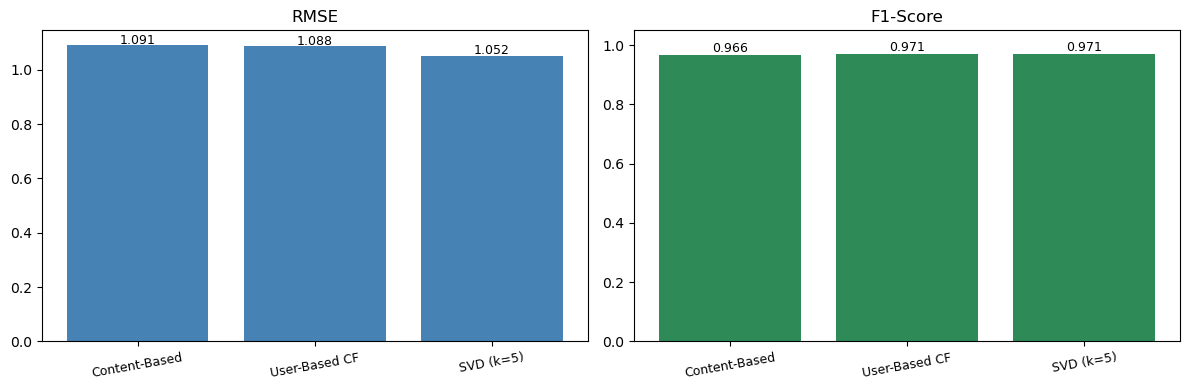

In [43]:
# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

models = comparison.columns.tolist()
x = np.arange(len(models))

# Chart 1: RMSE (primary prediction accuracy metric)
rmse_vals = comparison.loc['RMSE'].values
axes[0].bar(x, rmse_vals, color='steelblue')
for xi, v in zip(x, rmse_vals):
    axes[0].text(xi, v + 0.005, f'{v:.3f}', ha='center', fontsize=9)
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=10, fontsize=9)
axes[0].set_title('RMSE')

# Chart 2: F1-Score
f1_vals = comparison.loc['F1'].values
axes[1].bar(x, f1_vals, color='seagreen')
for xi, v in zip(x, f1_vals):
    axes[1].text(xi, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)

axes[1].set_xticks(x)
axes[1].set_xticklabels(models, rotation=10, fontsize=9)
axes[1].set_title('F1-Score')
axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

---
## 8. Conclusion

### 8.1 Model Comparison Summary

Three recommender systems were implemented and evaluated on a held-out test set (24,784 interactions). The validation set was used exclusively for hyperparameter tuning; final metrics are reported on the test set only.

| Metric | Content-Based | User-Based CF | SVD |
|---|---|---|---|
| **RMSE** | 1.0907 | 1.0877 | **1.0518** |
| **MAE** | **0.6491** | 0.7253 | 0.6553 |
| Recall (thr=4) | 0.9852 | 0.9999 | 0.9987 |
| Precision (thr=4) | **0.9483** | 0.9437 | 0.9453 |
| F1 (thr=4) | 0.9664 | 0.9710 | **0.9712** |

**SVD achieves the best RMSE and F1.** Content-based achieves the best MAE and Precision. User-based CF is competitive on classification metrics only because almost all its predictions default to the global mean which yields near-perfect Recall, while having virtually no personalized recommendation ability.


All of the F1 measures are over .96. A large portion of this can be attributed to the skewed nature of the rating distribution 94% of actual ratings are ≥ 4). In essence, if a model simply predicted values near the global mean value (≈ 5.5), it would have classified nearly all of the interactions as "relevant". Therefore these metrics demonstrate that none of the models failed significantly,rather than as evidence that all three models are equally strong recommenders.

### 8.2 Limitations

**1. Rating distribution skew (73% at rating 6).** Almost three-quarters of all interactions carry the maximum possible rating. This means: (a) classification metrics (Recall, Precision, F1) are inflated for every model - a predictor that always outputs 6 would achieve near-perfect Recall; (b) RMSE and MAE differences between models are compressed into a narrow band (1.05–1.09), making strong quantitative conclusions difficult.

**2. Extreme item sparsity (median = 1 rating per recipe).** The dataset has 62,517 recipes, of which 10.8% have zero training ratings (cold-start items in the val/test splits). This is the primary driver of CF failure and limits what SVD can learn about item latent factors.

**3. Review text not utilised.** The `train.csv` file includes a free-text `review` column for every interaction. This rich source of user preference information was not used in any of the three models. Sentiment analysis on reviews or keyword extraction could significantly improve content-based and CF models.

**4. TF-IDF semantic limitations.** Vocabulary-based similarity cannot capture semantic equivalences ('pasta bake' vs 'macaroni gratin') or modifiers ('sugar-free', 'dairy-free') that fundamentally change what a recipe is like. The model groups recipes by textual similarity rather than culinary similarity.

### 8.3 What Could Be Improved with More Time

**1. Hybrid model (content-based + SVD).** A weighted-average hybrid  would combine the cold-start robustness of the content-based model with SVD's superior warm-user accuracy. A simple switching strategy (use content-based if a user has fewer than 5 training ratings; use SVD otherwise) would already improve average performance meaningfully.

**2. Minimum interaction filtering.** Removing recipes with fewer than 3 ratings and users with fewer than 5 ratings from the training set would concentrate the available signal, reduce cold-start noise in the evaluation, and produce more reliable latent factor estimates for SVD.

**3. Review-text sentiment as implicit feedback.** Extracting positive/negative sentiment from the `review` field using a simple lexicon or classifier would provide a richer signal than the star rating alone. A recipe that receives a rating of 6 with a review saying 'too salty' carries different information from one reviewed as 'absolutely perfect'.

**4. Better text representations for content-based.** Replacing TF-IDF with pre-trained word embeddings (Word2Vec, GloVe) or contextual embeddings (BERT) would capture semantic similarity far more accurately. For example, 'olive oil', 'extra-virgin olive oil', and 'EVOO' would map to nearby representations rather than being treated as completely different tokens.
